In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.kernel_approximation import Nystroem,RBFSampler

In [2]:
GAMMA=0.9
ALPHA=.1
SMALL_ENOUGH=1e-3
ALL_POSSIBLE_ACTIONS=('U','D','L','R')
ACTION2INT={a:i for i,a in enumerate(ALL_POSSIBLE_ACTIONS)}
INT2ONEHOT=np.eye(len(ALL_POSSIBLE_ACTIONS))

In [3]:
class Grid:
    def __init__(self,rows,cols,start):
        self.rows=rows
        self.cols=cols
        self.i=start[0]
        self.j=start[1]
    
    def set(self,rewards,actions):
        self.rewards=rewards
        self.actions=actions
        
    def reset(self):
        self.i=2
        self.j=0
        return (self.i,self.j)
    
    def set_state(self,s):
        self.i=s[0]
        self.j=s[1]
    
    def current_state(self):
        return (self.i,self.j)

    def is_terminal(self,s):
        return s not in self.actions

    def get_next_state(self,s,a):
        i,j=s[0],s[1]
        if a in self.actions[i,j]:
            if a=='U':
                i -=1
            if a=='D':
                i +=1
            if a=='L':
                j -=1
            if a=='R':
                j +=1
        return i,j

    def move (self,action):
        if action in self.actions[(self.i,self.j)]:
            if action =='U':
                self.i -=1
            if action =='D':
                self.i +=1
            if action =='R':
                self.j +=1
            if action =='L':
                self.j -=1
            
        return self.rewards.get((self.i,self.j),0)

    def undo_move (self,action):
        if action =='U':
            self.i +=1
        if action =='D':
            self.i -=1
        if action =='R':
            self.j -=1
        if action =='L':
            self.j +=1
        assert(self.current_state() in self.all_stats())

    def game_over (self):
        return (self.i,self.j) not in self.actions

    def all_states(self):
        return set(self.actions.keys()) | set (self.rewards.keys())

In [4]:
def print_values(V,g):
    for i in range (g.rows):
        print("--------------------------")
        for j in range(g.cols):
            v=V.get((i,j),0)
            if v >=0:
                print(" %.2f |"% v,end="")
            else:
                print("%.2f |" %v,end="")
        print("")
        
        
def print_policy(P,g):
    for i in range(g.rows):
        print("----------------------------")
        for j in range(g.cols):
            a=P.get((i,j),' ')
            print(" %s |" %a,end="")
        print("")
    


In [5]:
def standard_grid(step_cost=-.1):
    g=Grid(3,4,(2,0))
    rewards={
        (0,0):step_cost,
        (0,1):step_cost,
        (0,2):step_cost,
        (1,0):step_cost,
        (1,2):step_cost,
        (2,0):step_cost,
        (2,1):step_cost,
        (2,2):step_cost,
        (2,3):step_cost,
        (0,3):1,
        (1,3):-1
        }

    actions={
        (0,0):('D','R'),
        (0,1):('L','R'),
        (0,2):('L','R','D'),
        (1,0):('U','D'),
        (1,2):('R','U','D'),
        (2,0):('U','R'),
        (2,1):('L','R'),
        (2,2):('L','R','U'),
        (2,3):('L','U')
    }
    
    
    g.set(rewards,actions)
    return g
    

In [6]:
def epsilon_greedy(model,s,eps=.1):
    p=np.random.random()
    if p <(1-eps):
        values=model.predict_all_actions(s)
        return ALL_POSSIBLE_ACTIONS[np.argmax(values)]
    else:
        return np.random.choice(ALL_POSSIBLE_ACTIONS)

In [7]:
def one_hot(k):
    return INT2ONEHOT[k]

In [8]:
def merge_state_action(s,a):
    ai=one_hot(ACTION2INT[a])
    return np.concatenate((s,ai))

In [9]:
def gather_samples(grid,n_episodes=10000):
    samples=[]
    for _ in range(n_episodes):
        s=grid.reset()
        
        while not grid.game_over():
            a=np.random.choice(ALL_POSSIBLE_ACTIONS)
            sa=merge_state_action(s,a)
            samples.append(sa)
            r=grid.move(a)
            s=grid.current_state()
    return samples

In [10]:
class Model:
    def __init__(self,grid):
        samples=gather_samples(grid)
        self.featurizer = RBFSampler()
        self.featurizer.fit(samples)
        dims=self.featurizer.n_components
        
        self.w=np.zeros(dims)
        
    def predict(self,s,a):
        sa=merge_state_action(s,a)
        x=self.featurizer.transform([sa])[0]
        return x @ self.w
        
        
    def predict_all_actions(self,s):
        return [self.predict(s,a) for a in ALL_POSSIBLE_ACTIONS]
    
    def grad(self,s,a):
        sa=merge_state_action(s,a)
        x=self.featurizer.transform([sa])[0]
        return x
    

rewards:
--------------------------
-0.10 |-0.10 |-0.10 | 1.00 |
--------------------------
-0.10 | 0.00 |-0.10 |-1.00 |
--------------------------
-0.10 |-0.10 |-0.10 |-0.10 |
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
(2, 0)
[0.30861861430780246, 0.17056986800997154, 0.170285177063948, 0.31341761619118996]
(2, 0)
[0.30861861430780246, 0.17056986800997154, 0.170285177063948, 0.31341761619118996]
0.31341761619118996


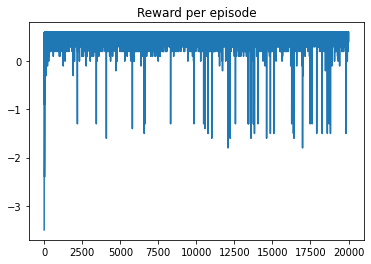

Values:
--------------------------
 0.61 | 0.80 | 1.00 | 0.00 |
--------------------------
 0.44 | 0.00 | 0.80 | 0.00 |
--------------------------
 0.31 | 0.46 | 0.62 | 0.45 |
policy:
----------------------------
 R | R | R |   |
----------------------------
 U |   | U |   |
----------------------------
 R | R | U | L |
state_visit_count:
         0        1        2        3
0  21012.0  20997.0  21543.0  19959.0
1  21079.0      0.0   1665.0     41.0
2  21649.0   1226.0   1164.0     32.0


In [11]:
if __name__=='__main__':
    grid=standard_grid()
    
    print('rewards:')
    print_values(grid.rewards,grid)
    
    
    model=Model(grid)
    reward_per_episode=[]
    state_visit_count={}
    
    n_episodes=20000
    for it in range(n_episodes):
        if (it+1) %1000==0:
            print(it+1)
            
        s=grid.reset()
        
        state_visit_count[s]=state_visit_count.get(s,0)+1
        episode_reward=0
        
        while not grid.game_over():
            a=epsilon_greedy(model,s)
            r=grid.move(a)
            s2=grid.current_state()
            state_visit_count[s2]=state_visit_count.get(s2,0)+1

            
            if grid.game_over():
                target=r 
            else:
                values=model.predict_all_actions(s2)
                target= r+  GAMMA*np.max(values)
                
            g=model.grad(s,a)
            err=target-model.predict(s,a)
            model.w += ALPHA*err*g
            
            
            episode_reward +=r
            
            s=s2
            
            
        
        reward_per_episode.append(episode_reward)
     
     
    s=grid.reset()
    print(s)
    print((model.predict_all_actions(s)))
    s=grid.reset()
    print(s)
    print(model.predict_all_actions(s))
    print(np.max(model.predict_all_actions(s)))
     
        
    plt.plot(reward_per_episode)
    plt.title('Reward per episode')
    plt.show()
    
    V={}
    greedy_policy={}
    states= grid.all_states()
    for s in states:
        if s in grid.actions:
            
            Values=model.predict_all_actions(s)
            
            V[s]=np.max(model.predict_all_actions(s))
            greedy_policy[s]=ALL_POSSIBLE_ACTIONS[np.argmax(model.predict_all_actions(s))]
        else:
            V[s]=0
            
    print('Values:')
    print_values(V,grid)
    print('policy:')
    print_policy(greedy_policy,grid)
    
    
    print('state_visit_count:')
    state_sample_count_arr=np.zeros((grid.rows,grid.cols))
    for i in range(grid.rows):
        for j in range(grid.cols):
            if (i,j) in state_visit_count:
                state_sample_count_arr[i,j]=state_visit_count[(i,j)]
    df= pd.DataFrame(state_sample_count_arr)
    print(df)
    